# Детекция аномалий + пайплайн

Пять детекторов: prob-интервал MSTL (level=99), modified Z-score на остатках, IsolationForest, LOF, Matrix Profile. Оценка - P/R/F1/AUC по разметке NAB.

In [1]:
# !pip install -q stumpy aeon


In [2]:
import sys, os
from pathlib import Path
ROOT = Path('.').resolve()
if not (ROOT / 'src').exists() and (ROOT.parent / 'src').exists():
    ROOT = ROOT.parent
    os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (14, 4)


In [3]:
from src.data import (
    load_panel, load_anomaly_labels, make_anomaly_mask,
    DAILY_SEASON, WEEKLY_SEASON, FREQ,
)
from src.anomaly import (
    modified_zscore, prob_interval_anomalies,
    isolation_forest_panel, lof_panel, matrix_profile_anomalies,
    score_anomalies, ks_drift_detection,
)

panel = load_panel()
windows, points = load_anomaly_labels()
anom_true = make_anomaly_mask(panel, windows)
print(f'Panel: {panel.shape}, аномальных точек: {int(anom_true.sum())} ({100*anom_true.mean():.1f}%)')


Panel: (12093, 3), аномальных точек: 1204 (10.0%)


## Probabilistic interval (MSTL, level=99)

In [4]:
from statsforecast import StatsForecast
from statsforecast.models import MSTL

H = DAILY_SEASON
sf = StatsForecast(
    models=[MSTL(season_length=[DAILY_SEASON, WEEKLY_SEASON], alias='MSTL')],
    freq=FREQ, n_jobs=-1,
)
# обучаем на всем panel, in-sample fitted с интервалом
fcst = sf.forecast(df=panel, h=H, level=[99], fitted=True)
fitted = sf.forecast_fitted_values()

# Привязываем к panel (in-sample покрывает train, последние H - forecast)
fitted_full = panel.merge(
    fitted[['unique_id','ds','MSTL','MSTL-lo-99','MSTL-hi-99']],
    on=['unique_id','ds'], how='left',
)
anom_prob = ((fitted_full['y'] < fitted_full['MSTL-lo-99']) |
             (fitted_full['y'] > fitted_full['MSTL-hi-99'])).fillna(False).astype(int)
print(f'Method 1 (prob interval): predicted={int(anom_prob.sum())} anomalies')


Method 1 (prob interval): predicted=126 anomalies


## Modified Z-score на остатках MSTL

In [5]:
fitted_full['residual'] = fitted_full['y'] - fitted_full['MSTL']

anom_zscore = pd.Series(0, index=fitted_full.index)
for uid, g in fitted_full.groupby('unique_id'):
    r = g['residual'].fillna(0).values
    anom_zscore.loc[g.index] = modified_zscore(r, k=3.0)
print(f'Method 2 (z-score): predicted={int(anom_zscore.sum())} anomalies')


Method 2 (z-score): predicted=259 anomalies


## IsolationForest

In [6]:
anom_iforest = isolation_forest_panel(panel, contamination=0.1)
print(f'Method 3 (IForest): predicted={int(anom_iforest.sum())} anomalies')


Method 3 (IForest): predicted=1209 anomalies


## Local Outlier Factor

In [7]:
anom_lof = lof_panel(panel, contamination=0.1, n_neighbors=50)
print(f'Method 4 (LOF): predicted={int(anom_lof.sum())} anomalies')


Method 4 (LOF): predicted=1209 anomalies


## Matrix Profile

In [8]:
anom_mp = matrix_profile_anomalies(panel, window=DAILY_SEASON, z_threshold=2.5)
print(f'Method 5 (Matrix Profile): predicted={int(anom_mp.sum())} anomalies')


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Method 5 (Matrix Profile): predicted=1558 anomalies


## Сравнение методов по разметке NAB

In [9]:
methods = {
    'prob_interval_MSTL': anom_prob,
    'zscore_residual_MSTL': anom_zscore,
    'IsolationForest': anom_iforest,
    'LOF': anom_lof,
    'MatrixProfile': anom_mp,
}
rows = []
for name, preds in methods.items():
    scores = score_anomalies(anom_true.values, preds.values)
    rows.append({'method': name, **scores})
methods_df = pd.DataFrame(rows).set_index('method').sort_values('f1', ascending=False)
methods_df.to_csv('data/processed/anomaly_methods_comparison.csv')
methods_df.style.format({'precision':'{:.3f}','recall':'{:.3f}','f1':'{:.3f}','auc':'{:.3f}'})


,precision,recall,f1,auc,n_predicted,n_actual
method,,,,,,
MatrixProfile,0.194,0.251,0.219,0.568,1558,1204
LOF,0.193,0.194,0.193,0.552,1209,1204
IsolationForest,0.190,0.191,0.191,0.551,1209,1204
zscore_residual_MSTL,0.151,0.032,0.053,0.506,259,1204
prob_interval_MSTL,0.143,0.015,0.027,0.503,126,1204


Лучший метод по F1: MatrixProfile


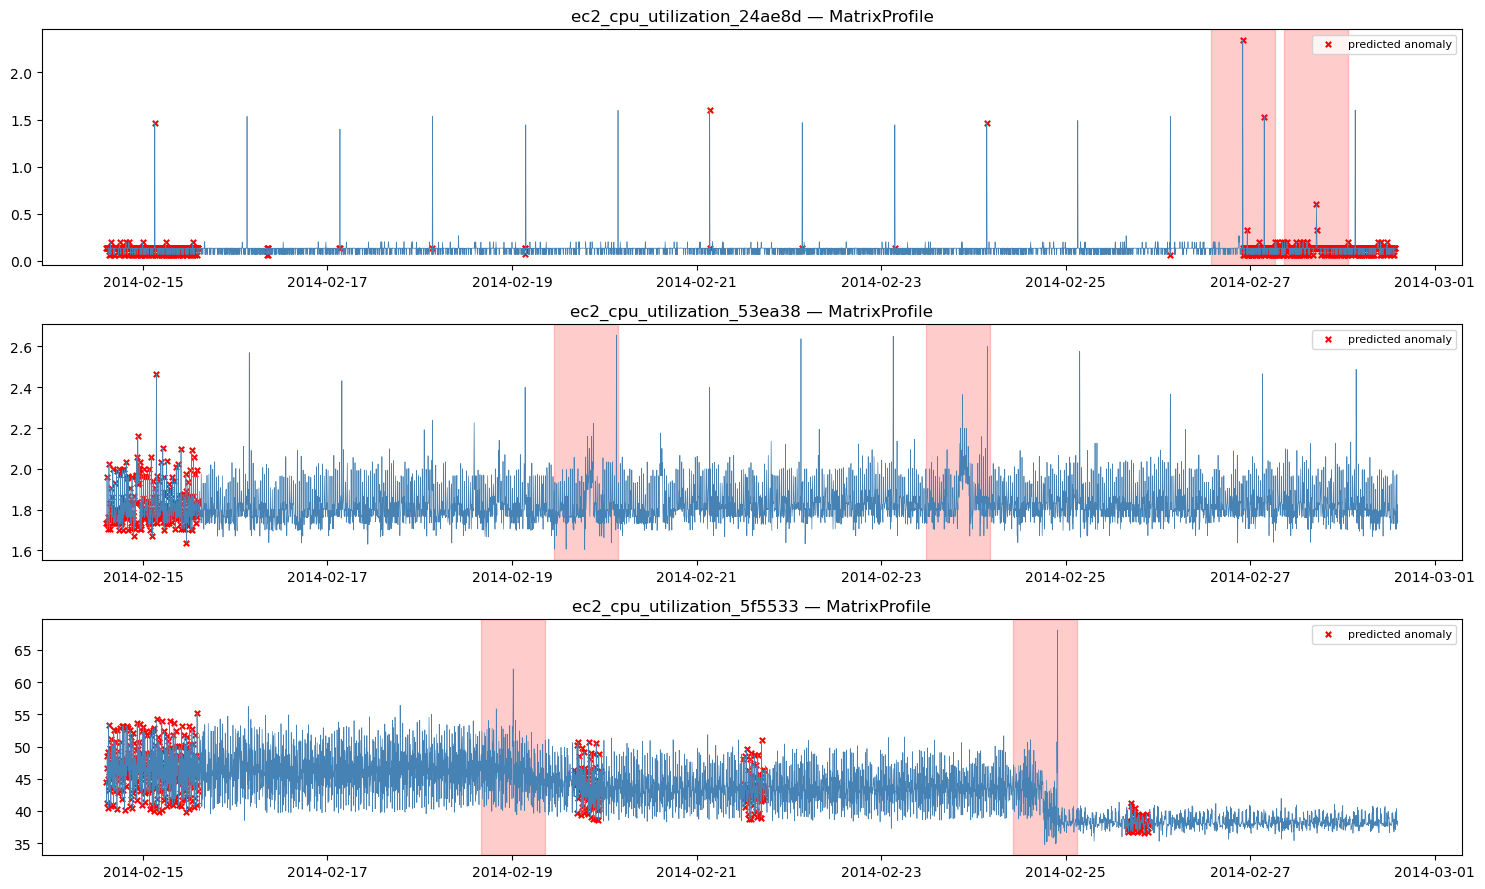

In [10]:
# Визуализация: лучший метод на одном ряду
best_method = methods_df.index[0]
print(f'Лучший метод по F1: {best_method}')
best_pred = methods[best_method]

fig, axes = plt.subplots(3, 1, figsize=(15, 9), sharex=False)
for ax, uid in zip(axes, panel['unique_id'].unique()):
    mask = panel['unique_id'] == uid
    sub = panel[mask].reset_index(drop=False)
    true_sub = anom_true[mask].reset_index(drop=True)
    pred_sub = best_pred[mask].reset_index(drop=True)
    ax.plot(sub['ds'], sub['y'], color='steelblue', linewidth=0.5)
    # окна NAB
    for start, end in windows.get(uid, []):
        ax.axvspan(start, end, color='red', alpha=0.2)
    # предсказанные точки
    pred_points = sub[pred_sub == 1]
    ax.scatter(pred_points['ds'], pred_points['y'], color='red', s=15, marker='x', label='predicted anomaly')
    ax.set_title(f'{uid} - {best_method}')
    ax.legend(fontsize=8, loc='upper right')
plt.tight_layout()
plt.savefig(f'report/figures/05_anomalies_{best_method}.png', dpi=120, bbox_inches='tight')
plt.show()


Красные окна - истинные интервалы NAB. Крестики - предсказания детектора.

## Drift detection через KS-test

ec2_cpu_utilization_24ae8d: drift points=4


ec2_cpu_utilization_53ea38: drift points=0


ec2_cpu_utilization_5f5533: drift points=1


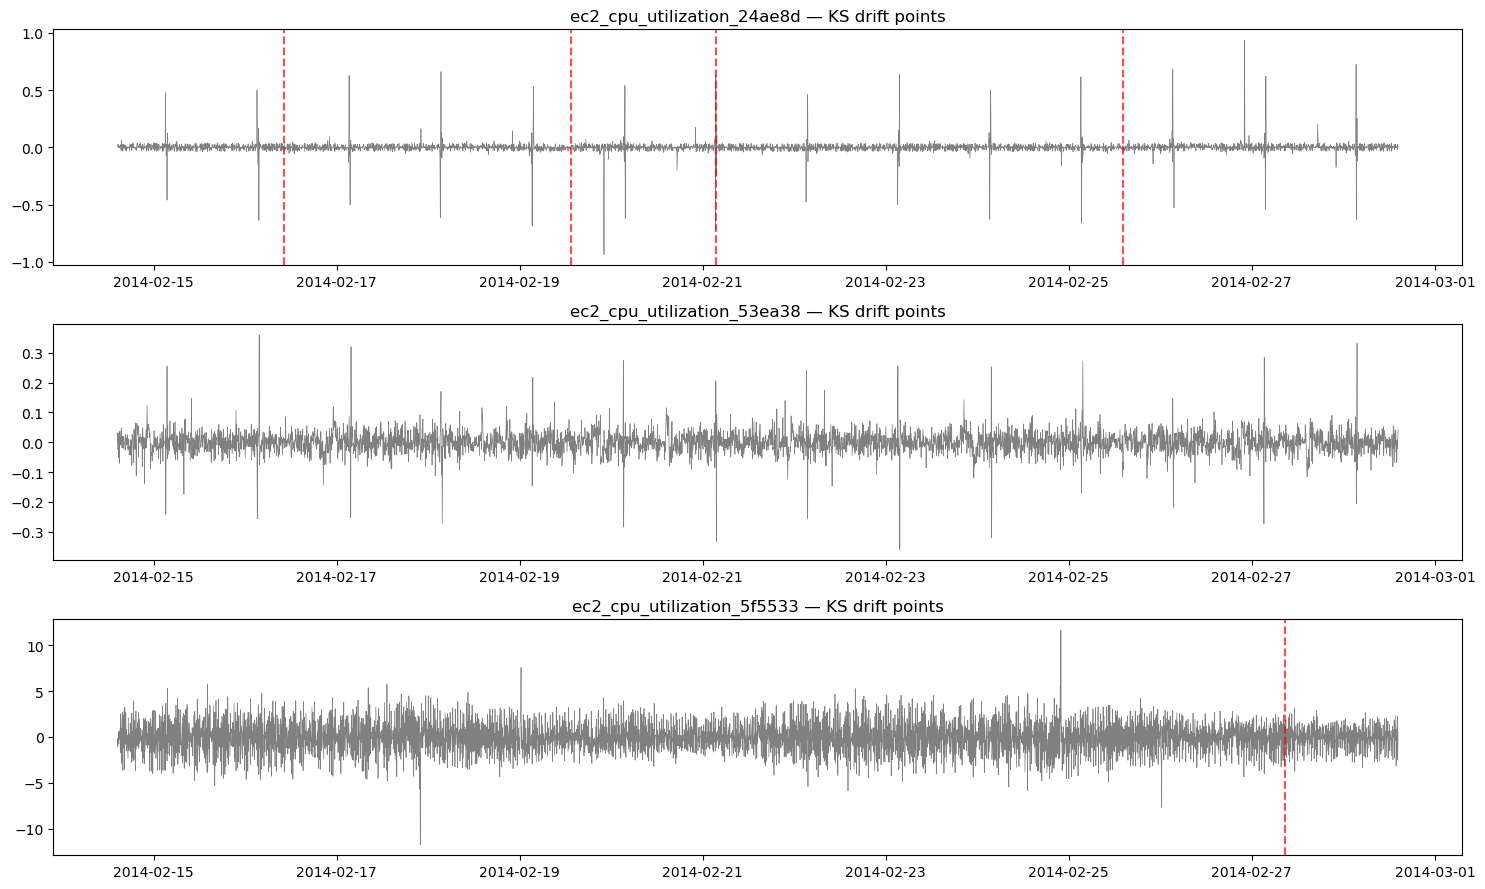

In [11]:
# Дрейф ищем на остатках MSTL
drift_results = {}
for uid in panel['unique_id'].unique():
    r = fitted_full[fitted_full['unique_id']==uid]['residual'].fillna(0).values
    drift_idx = ks_drift_detection(r, window_size=200, threshold=0.01)
    drift_results[uid] = drift_idx
    print(f'{uid}: drift points={len(drift_idx)}')

fig, axes = plt.subplots(3, 1, figsize=(15, 9), sharex=False)
for ax, uid in zip(axes, panel['unique_id'].unique()):
    sub = fitted_full[fitted_full['unique_id']==uid].reset_index(drop=True)
    ax.plot(sub['ds'], sub['residual'], linewidth=0.5, color='gray')
    for idx in drift_results[uid]:
        ax.axvline(sub.iloc[idx]['ds'], color='red', linestyle='--', alpha=0.7)
    ax.set_title(f'{uid} - KS drift points')
plt.tight_layout()
plt.savefig('report/figures/05_drift.png', dpi=120, bbox_inches='tight')
plt.show()


## Пайплайн (`src/pipeline.py`)

In [12]:
# End-to-end запуск через CLI или функцией
from src.pipeline import run_pipeline

summary = run_pipeline(
    forecast_model='MSTL',
    anomaly_method='zscore_resid',
)
print(pd.Series(summary['forecast_metrics_avg']))
print()
print(pd.Series(summary['anomaly_scores']))
print()
print(f"fit_time={summary['fit_time_s']}s, forecast_time={summary['forecast_time_s']}s, detect_time={summary['detect_time_s']}s")


mae      0.857654
mase     1.065913
rmse     1.093971
smape    0.068424
dtype: float64

precision         0.107628
recall            0.085548
f1                0.095326
auc               0.503560
n_predicted     957.000000
n_actual       1204.000000
dtype: float64

fit_time=9.83s, forecast_time=0.001s, detect_time=0.002s


### Сравнение нескольких конфигураций пайплайна

In [13]:
configs = [
    ('SeasonalNaive', 'zscore_resid'),
    ('MSTL', 'zscore_resid'),
    ('MSTL', 'isolation_forest'),
    ('MSTL', 'matrix_profile'),
]
results = []
for fm, am in configs:
    s = run_pipeline(forecast_model=fm, anomaly_method=am)
    results.append({
        'forecast': fm,
        'anomaly': am,
        'mae': s['forecast_metrics_avg'].get('mae', np.nan),
        'precision': s['anomaly_scores']['precision'],
        'recall': s['anomaly_scores']['recall'],
        'f1': s['anomaly_scores']['f1'],
        'fit_s': s['fit_time_s'],
        'detect_s': s['detect_time_s'],
    })
pipeline_compare = pd.DataFrame(results)
pipeline_compare.style.format({'mae':'{:.3f}','precision':'{:.3f}','recall':'{:.3f}','f1':'{:.3f}','fit_s':'{:.1f}','detect_s':'{:.1f}'}).background_gradient(cmap='RdYlGn_r', subset=['mae'])


,forecast,anomaly,mae,precision,recall,f1,fit_s,detect_s
0,SeasonalNaive,zscore_resid,0.281,0.068,0.119,0.087,2.6,0.0
1,MSTL,zscore_resid,0.858,0.108,0.086,0.095,9.7,0.0
2,MSTL,isolation_forest,0.858,0.234,0.118,0.157,9.6,0.3
3,MSTL,matrix_profile,0.858,0.194,0.251,0.219,9.7,0.1


### Performance benchmarks

In [14]:
import time

# Время на ряд (1 итерация)
print('Один прогон pipeline (полный panel, h=288):')
for fm in ['SeasonalNaive', 'MSTL', 'AutoETS']:
    t0 = time.perf_counter()
    run_pipeline(forecast_model=fm, anomaly_method='zscore_resid')
    print(f'  {fm:15s}: {time.perf_counter()-t0:.2f} s')


Один прогон pipeline (полный panel, h=288):


  SeasonalNaive  : 2.70 s


  MSTL           : 9.62 s


  AutoETS        : 7.73 s


In [15]:
# версии пакетов для воспроизводимости
try:
    import session_info
    session_info.show(html=False)
except ImportError:
    import sys, platform
    print(f'Python: {sys.version}')
    print(f'Platform: {platform.platform()}')


Python: 3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 11:23:37) [Clang 14.0.6 ]
Platform: macOS-26.5-arm64-arm-64bit-Mach-O
